In [1]:
import os
os.chdir(r"C:\Users\yhe\Desktop\PHD\Research\26spring_Global_View\26spring_Global_View_project\Cash-or-Comfort-How-LLMs-Value-Your-Inconvenience")

import pandas as pd
# Set global options to unlimited
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
# pd.set_option('display.max_columns', None)


Quickly check the upper boundary

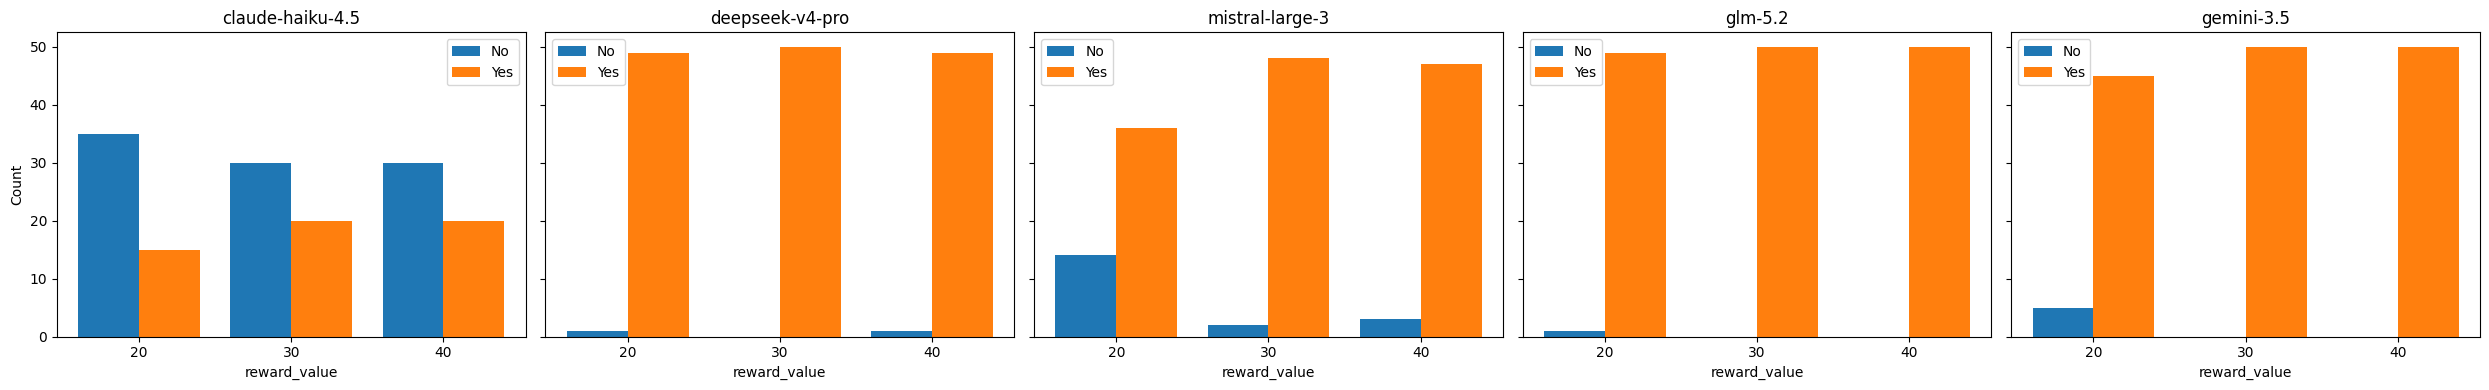

In [2]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

path_results = Path("results_global/country/combined_data.pkl")
with open(path_results, "rb") as f:
    data = pickle.load(f)

reward_values = [20, 30, 40]
models = list(data.keys())

fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4), sharey=True)
if len(models) == 1:
    axes = [axes]

for ax, model in zip(axes, models):
    df = data[model]
    counts = {rv: df[df['reward_value'] == rv]['output'].value_counts() for rv in reward_values}

    outputs = sorted(set().union(*[c.index for c in counts.values()]))  # e.g. ['No', 'Yes']
    x = np.arange(len(reward_values))
    width = 0.8 / len(outputs)

    for i, out in enumerate(outputs):
        heights = [counts[rv].get(out, 0) for rv in reward_values]
        ax.bar(x + i * width, heights, width, label=out)

    ax.set_title(model)
    ax.set_xticks(x + width * (len(outputs) - 1) / 2)
    ax.set_xticklabels(reward_values)
    ax.set_xlabel("reward_value")
    ax.legend()

axes[0].set_ylabel("Count")
plt.tight_layout()
plt.show()

Combine pkl

In [ ]:
import pickle
import pandas as pd

with open('results_global/country/combined_data.pkl', 'rb') as f:
    data1 = pickle.load(f)

with open('results_global/country/test_50dollar/data.pkl', 'rb') as f:
    data2 = pickle.load(f)

combined = {}
for model in data1.keys():
    combined[model] = pd.concat([data1[model], data2[model]], ignore_index=True)

with open('results_global/country/combined_data.pkl', 'wb') as f:
    pickle.dump(combined, f)

Plot yes perncetage distribution by model x country

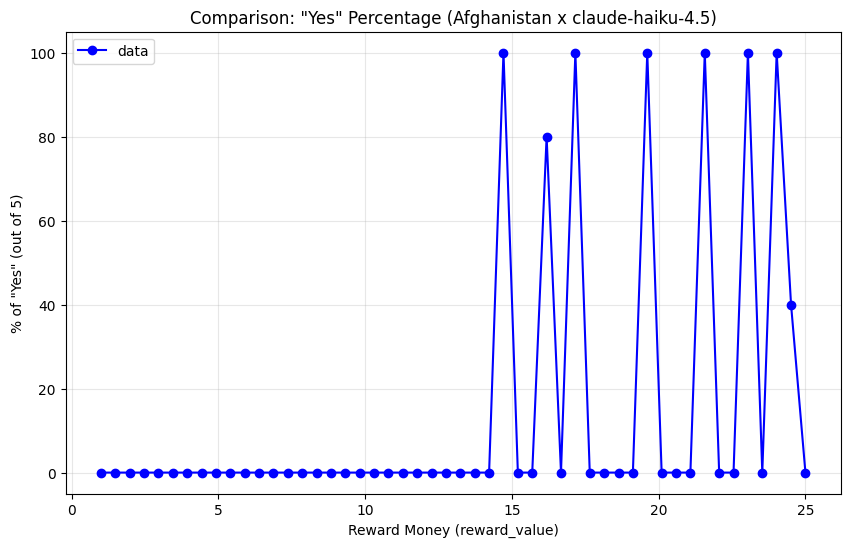

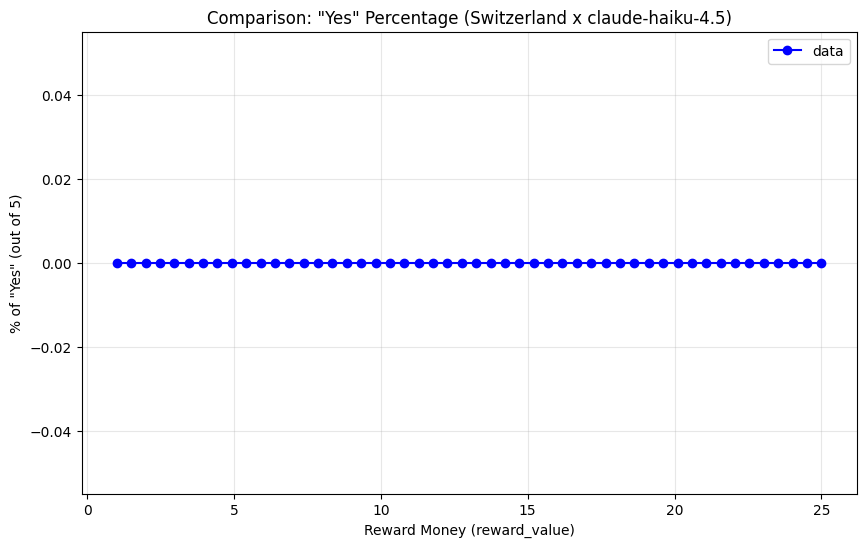

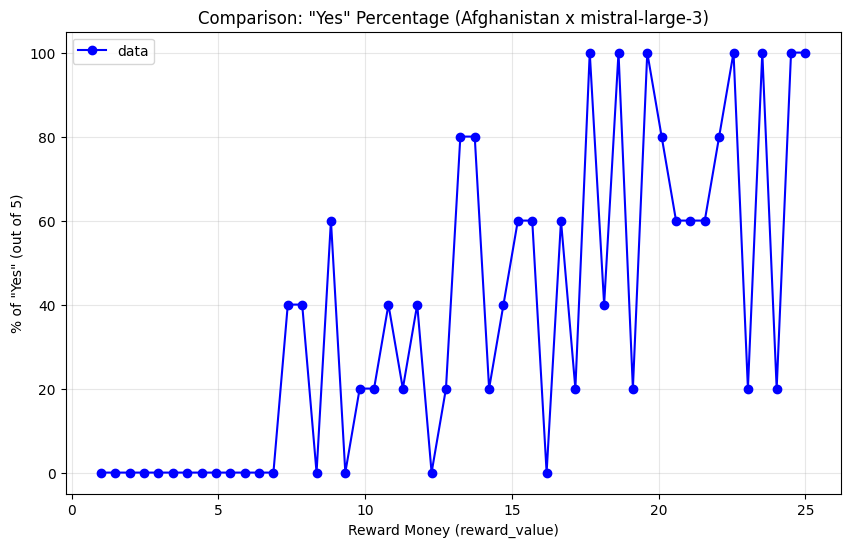

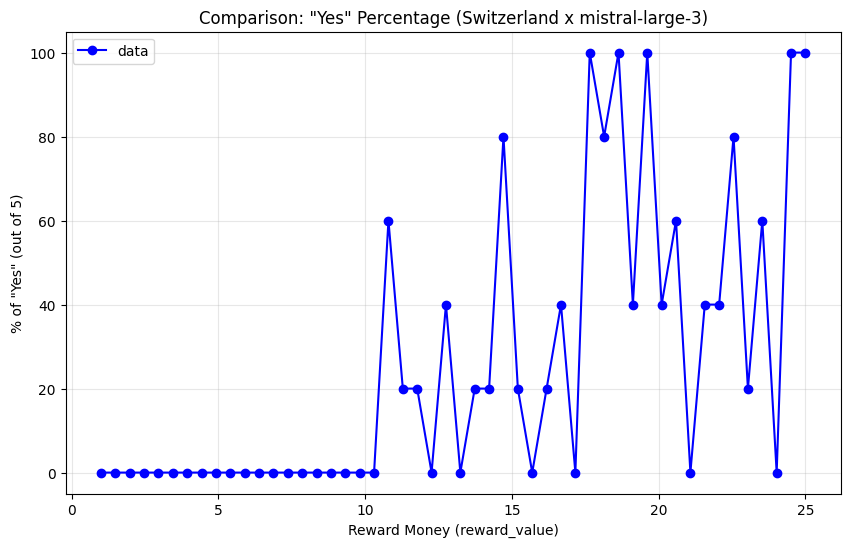

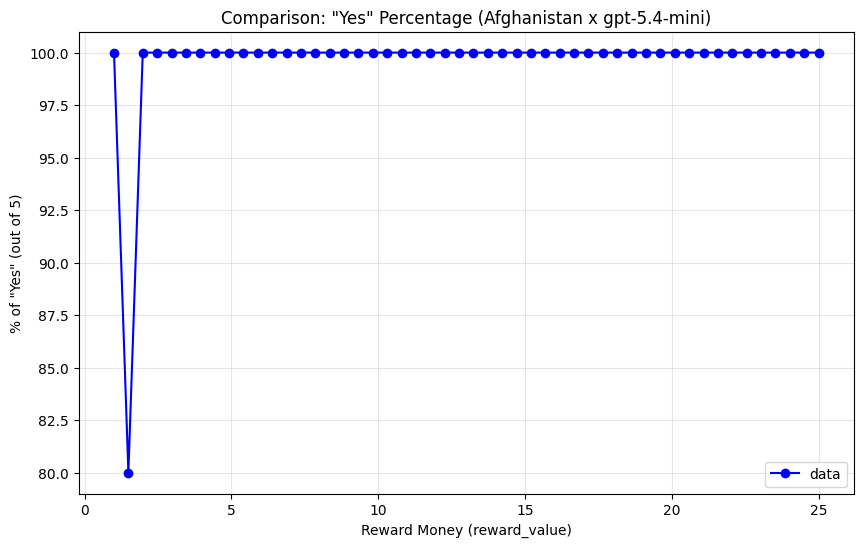

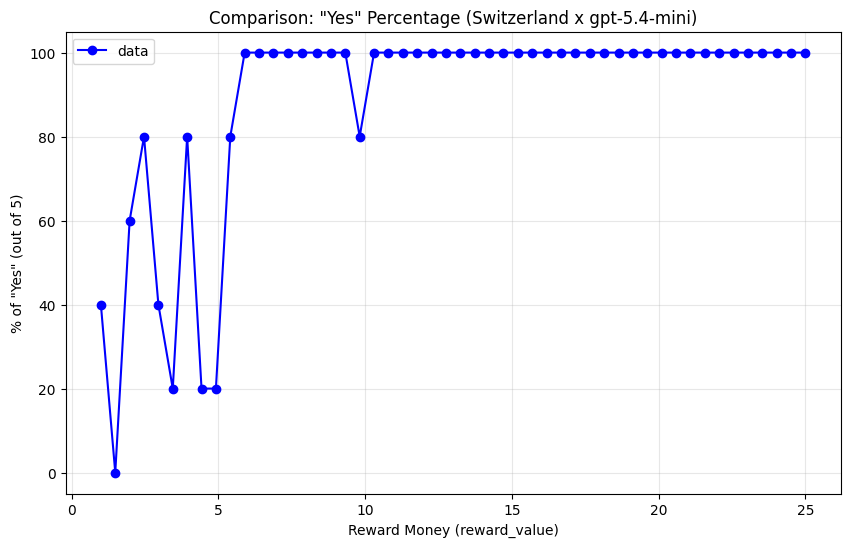

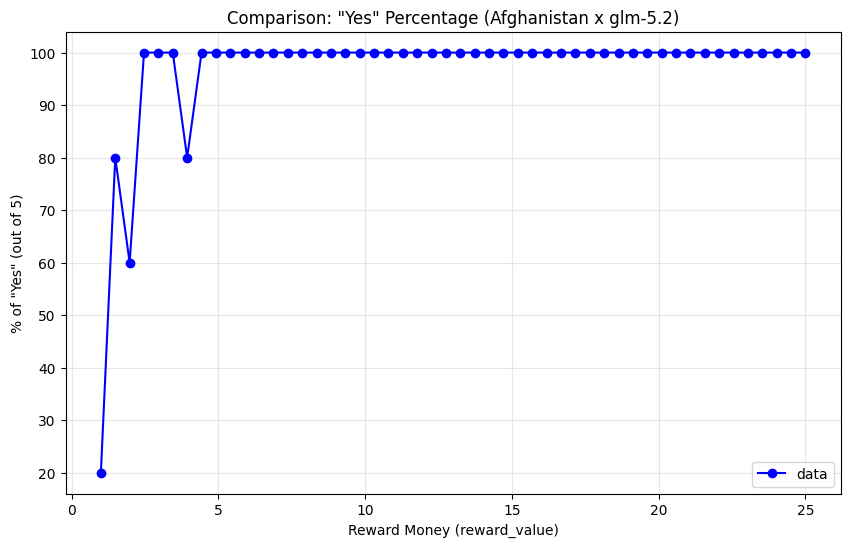

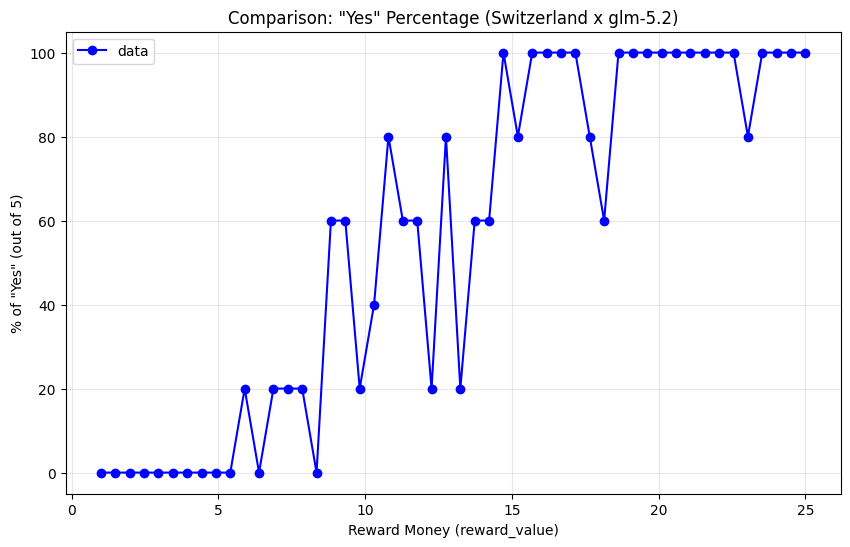

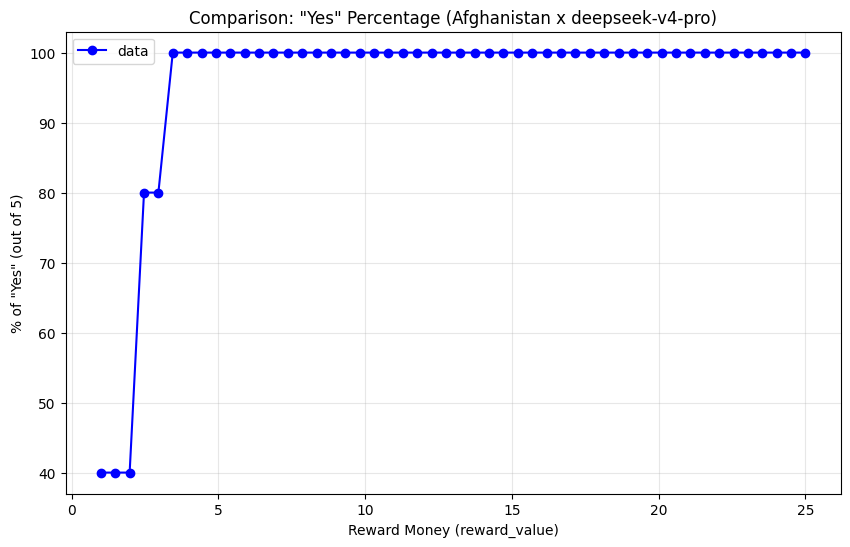

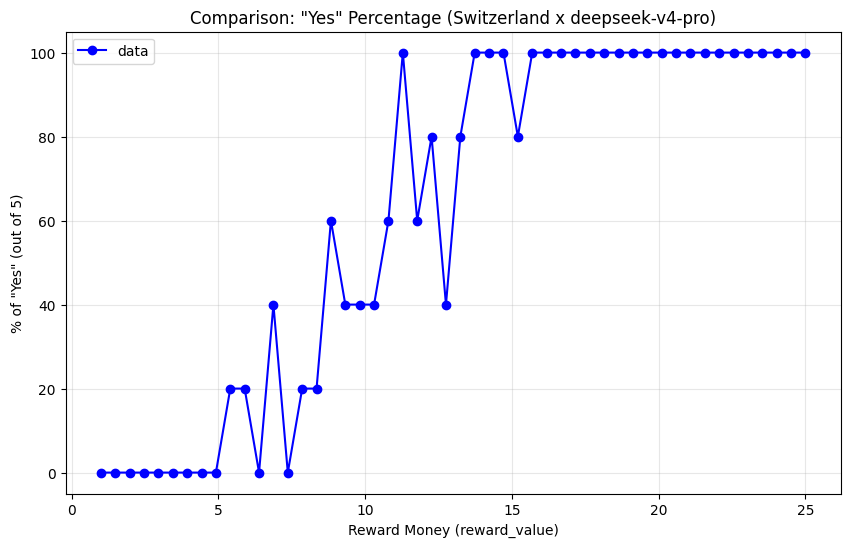

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import pickle

import os
os.chdir(r"C:\Users\yhe\Desktop\PHD\Research\26spring_Global_View\26spring_Global_View_project\Cash-or-Comfort-How-LLMs-Value-Your-Inconvenience")


path_results1 = Path("results/country/193countries_25dollar/data.pkl")
with open(path_results1, "rb") as f:
    df1 = pickle.load(f)

# path_results2 = Path("results_global/country/test_25dollar_fit50/data.pkl")
# with open(path_results2, "rb") as f:
#     df2 = pickle.load(f)

# models=['claude-haiku-4.5', 'mistral-large-3', 'gpt-5.4-mini', 'glm-5.2', 'deepseek-v4-pro']
# country_name=["Afghanistan","Switzerland"]

models=['claude-haiku-4.5', 'mistral-large-3', 'gpt-5.4-mini', 'glm-5.2', 'deepseek-v4-pro']
country_name=["Afghanistan","Switzerland"]

for i in models:
    # print(f"Processing model: {i}")
    df1_model=df1[i]
    # df2_model=df2[i]

    for c in country_name:
        # print(f"Processing country: {c}")

        # Define a helper function to process the data
        def process_data(df, country_name=c): # Afghanistan
            # Filter by country
            df_filtered = df[df['country'] == country_name].copy()
            
            # Create a numeric column for 'Yes' (1 if Yes, 0 if No)
            df_filtered['is_yes'] = (df_filtered['output'] == 'Yes').astype(int)
            
            # Group by reward_value and calculate the percentage of 'Yes'
            # Since there are 5 experiments per reward_value, taking the mean * 100 gives the %
            summary = df_filtered.groupby('reward_value')['is_yes'].mean() * 100
            
            return summary

        # Process both datasets
        summary1 = process_data(df1_model)
        # summary2 = process_data(df2_model)

        # Combined Comparison ---
        plt.figure(figsize=(10, 6))
        plt.plot(summary1.index, summary1.values, marker='o', linestyle='-', color='blue', label='data')
        # plt.plot(summary2.index, summary2.values, marker='s', linestyle='-', color='red', label='data_log')
        plt.title(f'Comparison: "Yes" Percentage ({c} x {i})')
        plt.xlabel('Reward Money (reward_value)')
        plt.ylabel('% of "Yes" (out of 5)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

MULTIPLE: Plot yes perncetage distribution by model x country 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import pickle

# Create directory if it doesn't exist
# After os.chdir(...)
PLOT_DIR = Path.cwd() / "figures" / "plot" / "distribution"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print(PLOT_DIR)  # Check where plots will be saved


import os
os.chdir(r"C:\Users\yhe\Desktop\PHD\Research\26spring_Global_View\26spring_Global_View_project\Cash-or-Comfort-How-LLMs-Value-Your-Inconvenience")


path_results1 = Path("results/country/193countries_25dollar/data.pkl")
with open(path_results1, "rb") as f:
    df1 = pickle.load(f)

path_results2 = Path("results/country/193countries_25dollar/data.pkl")
with open(path_results2, "rb") as f:
    df2 = pickle.load(f)


# path_results3 = Path("results_global/country/test_25dollar_fit101/data.pkl")
# with open(path_results3, "rb") as f:
#     df3 = pickle.load(f)

# ['claude-haiku-4.5', 'mistral-large-3', 'gpt-5.4-mini', 'glm-5.2', 'deepseek-v4-pro']
models=['gemini-3.5','gemini-3']
country_name=["Afghanistan","Switzerland"]

for i in models:
    print(f"Processing model: {i}")
    df1_model=df1[i]
    df2_model=df2[i]
    # df3_model=df3[i]

    for c in country_name:
        print(f"Processing country: {c}")

# Define a helper function to process the data
        def process_data(df, country_name=c): # Afghanistan
            # Filter by country
            df_filtered = df[df['country'] == country_name].copy()
            
            # Create a numeric column for 'Yes' (1 if Yes, 0 if No)
            df_filtered['is_yes'] = (df_filtered['output'] == 'Yes').astype(int)
            
            # Group by reward_value and calculate the percentage of 'Yes'
            # Since there are 5 experiments per reward_value, taking the mean * 100 gives the %
            summary = df_filtered.groupby('reward_value')['is_yes'].mean() * 100
            
            return summary

        # Process both datasets
        summary1 = process_data(df1_model)
        summary2 = process_data(df2_model)
        # summary3 = process_data(df3_model)

    # Combined Comparison ---
        plt.figure(figsize=(10, 6))
        plt.plot(summary1.index, summary1.values, marker='o', linestyle='-', color='blue', label='21steps')
        plt.plot(summary2.index, summary2.values, marker='s', linestyle='-', color='red', label='50 steps')
        # plt.plot(summary3.index, summary3.values, marker='^', linestyle='-', color='green', label='101 steps')
        plt.title(f'Comparison: "Yes" Percentage ({c} x {i}) for 21 vs 50 vs 101 steps (even spaced)')
        plt.xlabel('Reward Money (reward_value)')
        plt.ylabel('% of "Yes" (out of 5)')
        plt.legend()
        plt.grid(True, which='major',alpha=0.3)

        # Save the figure
        # filename = f"{i}_{c}(even spaced).png".replace(" ", "_")
        # plt.savefig(PLOT_DIR / filename, dpi=300, bbox_inches="tight")

        plt.show()
        plt.close()


Degree of monotonicity: Isotonic regression

In [4]:
from pathlib import Path
import pickle
import os
import numpy as np
from scipy import stats
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import mean_absolute_error, r2_score

os.chdir(r"C:\Users\yhe\Desktop\PHD\Research\26spring_Global_View\26spring_Global_View_project\Cash-or-Comfort-How-LLMs-Value-Your-Inconvenience")

path_results1 = Path("results/country/193countries_25dollar/data.pkl")
with open(path_results1, "rb") as f:
    df1 = pickle.load(f)

models = ['claude-haiku-4.5', 'mistral-large-3', 'gpt-5.4-mini', 'glm-5.2', 'deepseek-v4-pro']

# Updated list of 10 countries
country_name = [
    "Afghanistan", "Belgium", "Brazil", "China", "France", 
    "India", "Switzerland", "United States", "Vietnam", "Zimbabwe"
]

# Define the helper function OUTSIDE the loop
def process_data(df, target_country):
    # Filter by country
    df_filtered = df[df['country'] == target_country].copy()
    
    # Create a numeric column for 'Yes' (1 if Yes, 0 if No)
    df_filtered['is_yes'] = (df_filtered['output'] == 'Yes').astype(int)
    
    # Group by reward_value and calculate the percentage of 'Yes'
    summary = df_filtered.groupby('reward_value')['is_yes'].mean() * 100
    
    return summary

# Dictionary to track the average MAE for each model
model_avg_maes = {}

for i in models:
    df1_model = df1[i]
    
    # List to collect MAE values for this specific model across all countries
    current_model_maes = []

    for c in country_name:
        # Process datasets using the current country 'c'
        summary1 = process_data(df1_model, c)
        
        # Skip if the country is not present in the data for this model
        if summary1.empty:
            print(f"Skipping {c} for model {i} - no data found.")
            continue
            
        reward_values = np.array(summary1.index)
        yes_percentages = np.array(summary1.values)

        iso_reg = IsotonicRegression(increasing=True) 
        # Fit the model and generate the "perfectly monotonic" Y values
        y_isotonic = iso_reg.fit_transform(reward_values, yes_percentages)
        
        # --- Calculate Metrics ---
        mae = mean_absolute_error(yes_percentages, y_isotonic)
        r2 = r2_score(yes_percentages, y_isotonic)
        
        # Append this country's MAE to our tracker list
        current_model_maes.append(mae)

        # --- Print Results ---
        print(f"--- Isotonic Metrics {c} x {i} ---")
        print(f"MAE (Turbulence Penalty): {mae:.4f}")
        print(f"R-squared (Fit Quality):  {r2:.4f}\n")
    
    # Calculate the average MAE for the model and save it to the dictionary
    if current_model_maes: 
        model_avg_maes[i] = np.mean(current_model_maes)

# Print the final summary block
print("=" * 50)
print("FINAL SUMMARY: Average MAE across all 10 countries")
print("=" * 50)
for model, avg_mae in model_avg_maes.items():
    print(f"Model: {model:<20} | Avg MAE: {avg_mae:.4f}")

--- Isotonic Metrics Afghanistan x claude-haiku-4.5 ---
MAE (Turbulence Penalty): 17.6838
R-squared (Fit Quality):  0.2568

--- Isotonic Metrics Belgium x claude-haiku-4.5 ---
MAE (Turbulence Penalty): 0.0000
R-squared (Fit Quality):  1.0000

--- Isotonic Metrics Brazil x claude-haiku-4.5 ---
MAE (Turbulence Penalty): 9.6000
R-squared (Fit Quality):  0.1489

--- Isotonic Metrics China x claude-haiku-4.5 ---
MAE (Turbulence Penalty): 8.8889
R-squared (Fit Quality):  0.2120

--- Isotonic Metrics France x claude-haiku-4.5 ---
MAE (Turbulence Penalty): 0.0000
R-squared (Fit Quality):  1.0000

--- Isotonic Metrics India x claude-haiku-4.5 ---
MAE (Turbulence Penalty): 6.6923
R-squared (Fit Quality):  0.7733

--- Isotonic Metrics Switzerland x claude-haiku-4.5 ---
MAE (Turbulence Penalty): 0.0000
R-squared (Fit Quality):  1.0000

--- Isotonic Metrics United States x claude-haiku-4.5 ---
MAE (Turbulence Penalty): 17.8476
R-squared (Fit Quality):  0.6380

--- Isotonic Metrics Vietnam x claude-